Test Size =  0.65  Criterion =  entropy

True Pos 145
True Neg 16
False Pos 29
False Neg 70

Accuracy -  82.6923076923077
Accuracy score:  82.6923076923077 %
              precision    recall  f1-score   support

           0       0.83      0.90      0.87       161
           1       0.81      0.71      0.76        99

    accuracy                           0.83       260
   macro avg       0.82      0.80      0.81       260
weighted avg       0.83      0.83      0.82       260



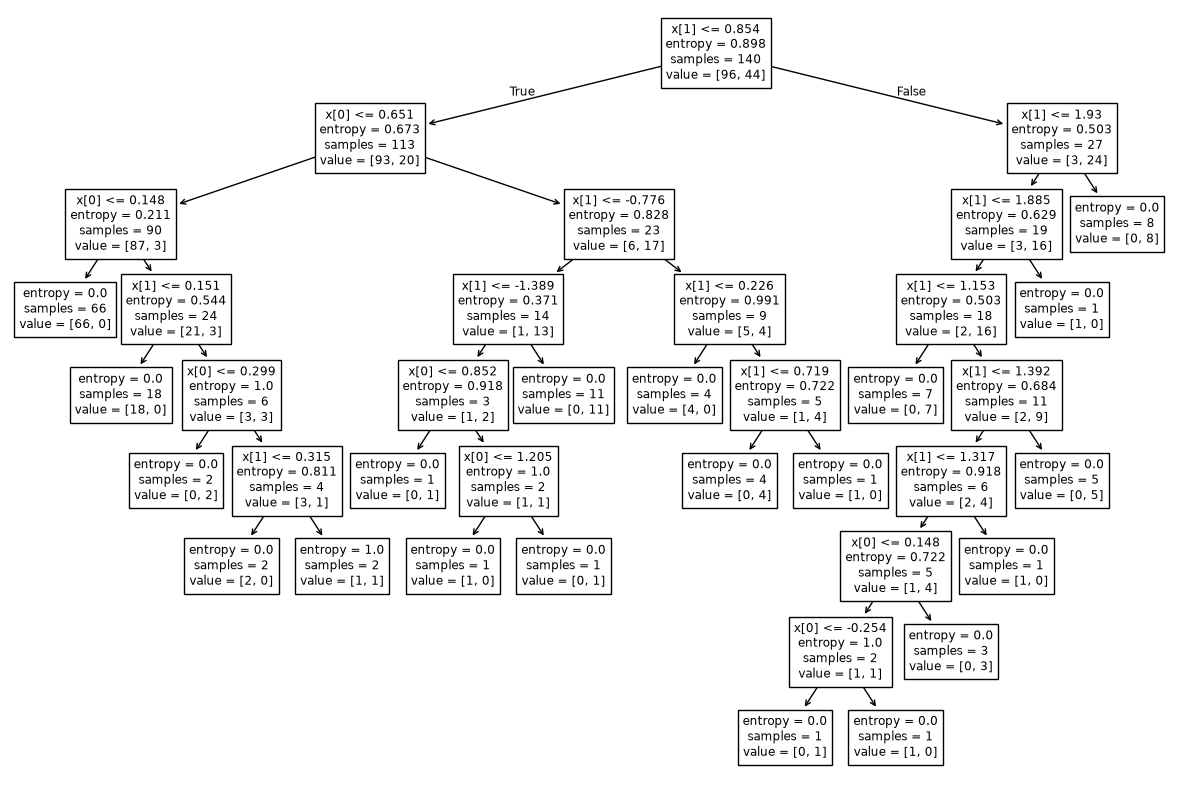

0.8269230769230769

In [20]:
import pandas as ps
import numpy as nm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn import metrics, tree


class SocialADS:
    def __init__(self, test_size, criterion, random_state=45):
        self.test_size = test_size
        self.criterion = criterion
        self.random_state = random_state

        print("Test Size = ", self.test_size, " Criterion = ", self.criterion)

    def import_data(self, path="D:\BDA 20\AIML-BDA-Lab-Work\data\Social_Network_Ads.csv"):
        self.df = ps.read_csv(path)
        # print(self.df.head())

    def split_columns(self):
        # print("Independent variable, X:")
        self.x = self.df.iloc[:, [2, 3]].values
        # print(self.x)

        # print("Dependent variable, Y:")
        self.y = self.df.iloc[:, 4].values
        # print(self.y)

    def train_test(self):
        self.x_train, self.x_test, self.y_train, self.y_test = train_test_split(
            self.x, self.y,
            test_size=self.test_size,
            random_state=self.random_state
        )

    def scale(self):
        self.sc_x = StandardScaler()
        self.x_train = self.sc_x.fit_transform(self.x_train)
        self.x_test = self.sc_x.transform(self.x_test)
        # print(self.x_test)

    def fit_classifier(self):
        self.classifier = DecisionTreeClassifier(criterion=self.criterion, random_state=0)
        self.classifier.fit(self.x_train, self.y_train)

    def predict(self):
        self.y_pred = self.classifier.predict(self.x_test)
        # print("\nActual: ", self.y_test)
        # print("Predicted: ", self.y_pred)

    def confusion_matrix(self):
        self.cm = confusion_matrix(self.y_test, self.y_pred)
        print("\nTrue Pos", self.cm[0][0])
        print("True Neg", self.cm[0][1])
        print("False Pos", self.cm[1][0])
        print("False Neg", self.cm[1][1])

    def manual_accuracy(self):
        cm = self.cm
        accuracy = (cm[0][0] + cm[1][1]) / (cm[0][0] + cm[1][1] + cm[1][0] + cm[0][1])
        print("\nAccuracy - ", accuracy * 100)
        return accuracy

    def builtin_accuracy(self):
        acc = metrics.accuracy_score(self.y_test, self.y_pred)
        print("Accuracy score: ", acc * 100, "%")
        return acc

    def report(self):
        print(classification_report(self.y_test, self.y_pred))

    # def predict_new(self, age, salary):
    #     new = nm.array([[age, salary]])
    #     new_scl = self.sc_x.transform(new)
    #     prediction = self.classifier.predict(new_scl)
    #     if prediction[0] == 1:
    #         print("Predicted to Purchase")
    #     else:
    #         print("Not Predicted to Purchase")

    def plot_tree(self):
        plt.figure(figsize=(15, 10))
        tree.plot_tree(self.classifier)
        plt.show()

    def run_all(self, path="D:\BDA 20\AIML-BDA-Lab-Work\data\Social_Network_Ads.csv"):
        self.import_data(path)
        self.split_columns()
        self.train_test()
        self.scale()
        self.fit_classifier()
        self.predict()
        self.confusion_matrix()
        self.manual_accuracy()
        acc = self.builtin_accuracy()
        self.report()
        self.plot_tree()
        return acc


# ---- Run with your chosen parameters ----
test_size_dym = 0.65
criterion_dym = 'entropy'
scl = SocialADS(test_size=test_size_dym, criterion=criterion_dym, random_state=45)
scl.run_all()

# # Example: predict a new data point
# scl.predict_new(29, 80000)